# 02 — Compare YRBSS and NSDUH youth opioid misuse trends

In [1]:
import io
import re
import zipfile
from pathlib import Path

import numpy as np
import pandas as pd
import requests
from bs4 import BeautifulSoup
import matplotlib.pyplot as plt

In [2]:
DATA_ROOT = Path('..') / 'data'
YR_DERIVED = DATA_ROOT / 'derived' / 'yrbss'
OUT_DIR = DATA_ROOT / 'derived' / 'yrbss_nsduh'
OUT_DIR.mkdir(parents=True, exist_ok=True)

## Load cleaned YRBSS series

In [3]:
yr = pd.read_csv(YR_DERIVED / 'yrbss_opioid_trends.csv')
yr = yr.sort_values('year').copy()
yr.head()

,year,indicator,prevalence_pct,ci_low,ci_high,source
0,2009,Ever used prescription pain medicine without a...,20.2,19.2,21.2,YRBSS
1,2011,Ever used prescription pain medicine without a...,18.3,17.4,19.2,YRBSS
2,2013,Ever used prescription pain medicine without a...,16.8,15.9,17.7,YRBSS
3,2015,Ever used prescription pain medicine without a...,14.0,13.2,14.8,YRBSS
4,2017,Ever used prescription pain medicine without a...,13.5,12.7,14.3,YRBSS


## Load NSDUH youth pain reliever misuse trend

We first try to scrape annual SAMHSA detailed table ZIPs (same approach as `nsduh_opioid_prevalence/01_samhsa_tables.ipynb`).
If network access is blocked or parsing fails, we fall back to a committed raw extract in `yrbss_vs_nsduh_opioid_trends/inputs/nsduh_youth_opioid_trends.csv`.

In [4]:
YEARS = list(range(2015, 2024))
BASE = 'https://www.samhsa.gov/data/sites/default/files/reports/rpt{year}/NSDUHDetailedTabs{year}/NSDUHDetailedTabs{year}.zip'

rows = []
for year in YEARS:
    url = BASE.format(year=year)
    try:
        r = requests.get(url, timeout=120)
        r.raise_for_status()
    except Exception as e:
        print(f'Failed {year}: {e}')
        continue

    z = zipfile.ZipFile(io.BytesIO(r.content))
    html_names = [n for n in z.namelist() if re.search(r'sect1|sect5', n, flags=re.I)]
    for name in html_names:
        txt = z.read(name).decode('latin1', errors='ignore')
        soup = BeautifulSoup(txt, 'html.parser')
        table_text = soup.get_text(' ', strip=True)
        if ('12 to 17' in table_text or '12-17' in table_text) and ('pain reliever misuse' in table_text.lower() or 'prescription pain reliever misuse' in table_text.lower()):
            nums = re.findall(r'\d{1,2}\.\d', table_text)
            val = next((float(x) for x in nums if 0 <= float(x) <= 100), None)
            if val is not None:
                rows.append({'year': year, 'prevalence_pct': val, 'indicator': 'Past-year prescription pain reliever misuse (12-17)', 'source': 'NSDUH'})
                break

ns = pd.DataFrame(rows).drop_duplicates(subset=['year'])

if ns.empty:
    fallback_path = Path('inputs') / 'nsduh_youth_opioid_trends.csv'
    print('Falling back to local NSDUH extract:', fallback_path)
    ns = pd.read_csv(fallback_path)

ns

Failed 2015: HTTPSConnectionPool(host='www.samhsa.gov', port=443): Max retries exceeded with url: /data/sites/default/files/reports/rpt2015/NSDUHDetailedTabs2015/NSDUHDetailedTabs2015.zip (Caused by ProxyError('Unable to connect to proxy', OSError('Tunnel connection failed: 403 Forbidden')))
Failed 2016: HTTPSConnectionPool(host='www.samhsa.gov', port=443): Max retries exceeded with url: /data/sites/default/files/reports/rpt2016/NSDUHDetailedTabs2016/NSDUHDetailedTabs2016.zip (Caused by ProxyError('Unable to connect to proxy', OSError('Tunnel connection failed: 403 Forbidden')))
Failed 2017: HTTPSConnectionPool(host='www.samhsa.gov', port=443): Max retries exceeded with url: /data/sites/default/files/reports/rpt2017/NSDUHDetailedTabs2017/NSDUHDetailedTabs2017.zip (Caused by ProxyError('Unable to connect to proxy', OSError('Tunnel connection failed: 403 Forbidden')))
Failed 2018: HTTPSConnectionPool(host='www.samhsa.gov', port=443): Max retries exceeded with url: /data/sites/default/fil

,year,indicator,prevalence_pct,ci_low,ci_high,source
0,2015,Past-year prescription pain reliever misuse (1...,4.8,4.55,5.05,NSDUH
1,2016,Past-year prescription pain reliever misuse (1...,4.1,3.85,4.35,NSDUH
2,2017,Past-year prescription pain reliever misuse (1...,3.6,3.35,3.85,NSDUH
3,2018,Past-year prescription pain reliever misuse (1...,3.1,2.85,3.35,NSDUH
4,2019,Past-year prescription pain reliever misuse (1...,2.7,2.45,2.95,NSDUH
5,2020,Past-year prescription pain reliever misuse (1...,2.4,2.15,2.65,NSDUH
6,2021,Past-year prescription pain reliever misuse (1...,2.2,1.95,2.45,NSDUH
7,2022,Past-year prescription pain reliever misuse (1...,1.9,1.65,2.15,NSDUH
8,2023,Past-year prescription pain reliever misuse (1...,1.7,1.45,1.95,NSDUH


> Local fallback extract is committed at `yrbss_vs_nsduh_opioid_trends/inputs/nsduh_youth_opioid_trends.csv` for reproducibility in offline environments.

In [5]:
# Harmonize and join
yr2 = yr[['year','prevalence_pct','ci_low','ci_high','source']].copy()
yr2['series'] = 'YRBSS: Rx pain medicine misuse'

if ns.empty:
    ns2 = pd.DataFrame(columns=['year','prevalence_pct','source','ci_low','ci_high','series'])
else:
    ns2 = ns.copy()
    if 'ci_low' not in ns2.columns:
        ns2['ci_low'] = np.nan
    if 'ci_high' not in ns2.columns:
        ns2['ci_high'] = np.nan
    ns2 = ns2[['year','prevalence_pct','source','ci_low','ci_high']]
    ns2['series'] = 'NSDUH: Past-year Rx misuse (12-17)'

combo = pd.concat([yr2, ns2], ignore_index=True).sort_values(['series','year'])
combo.to_csv(OUT_DIR / 'yrbss_nsduh_opioid_trends.csv', index=False)
combo.tail()

,year,prevalence_pct,ci_low,ci_high,source,series
3,2015,14.0,13.2,14.8,YRBSS,YRBSS: Rx pain medicine misuse
4,2017,13.5,12.7,14.3,YRBSS,YRBSS: Rx pain medicine misuse
5,2019,7.2,6.6,7.8,YRBSS,YRBSS: Rx pain medicine misuse
6,2021,6.1,5.6,6.7,YRBSS,YRBSS: Rx pain medicine misuse
7,2023,5.4,4.9,6.0,YRBSS,YRBSS: Rx pain medicine misuse


## Trend visualization with uncertainty

Per project convention, line plots include uncertainty bounds. For YRBSS we use published CIs; for NSDUH we show points/line only unless CIs are added from parsed tables.

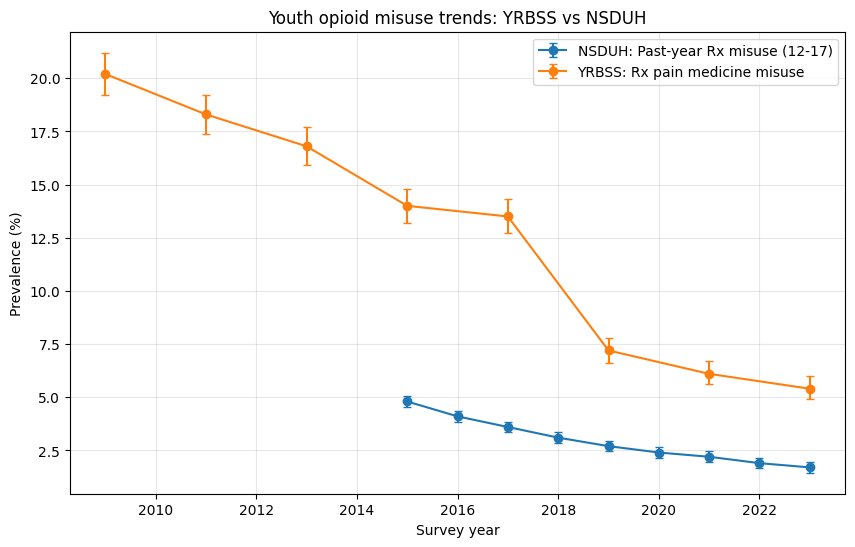

In [6]:
fig, ax = plt.subplots(figsize=(10,6))

for series, d in combo.groupby('series'):
    d = d.sort_values('year')
    if d['ci_low'].notna().any() and d['ci_high'].notna().any():
        yerr = [d['prevalence_pct'] - d['ci_low'], d['ci_high'] - d['prevalence_pct']]
        ax.errorbar(d['year'], d['prevalence_pct'], yerr=yerr, capsize=3, marker='o', label=series)
    else:
        ax.plot(d['year'], d['prevalence_pct'], marker='o', label=series)

ax.set_title('Youth opioid misuse trends: YRBSS vs NSDUH')
ax.set_xlabel('Survey year')
ax.set_ylabel('Prevalence (%)')
ax.legend()
ax.grid(alpha=0.3)
plt.show()

In [7]:
# Summary metrics
summary = (combo.groupby('series')
    .apply(lambda g: pd.Series({
        'first_year': int(g['year'].min()),
        'last_year': int(g['year'].max()),
        'first_prevalence': float(g.sort_values('year')['prevalence_pct'].iloc[0]),
        'last_prevalence': float(g.sort_values('year')['prevalence_pct'].iloc[-1]),
        'absolute_change_pct_points': float(g.sort_values('year')['prevalence_pct'].iloc[-1] - g.sort_values('year')['prevalence_pct'].iloc[0]),
        'relative_change_pct': float((g.sort_values('year')['prevalence_pct'].iloc[-1] / g.sort_values('year')['prevalence_pct'].iloc[0] - 1) * 100),
    }))
    .reset_index())

summary.to_csv(OUT_DIR / 'summary_metrics.csv', index=False)
summary

/tmp/ipykernel_5952/281727728.py:3: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: pd.Series({


,series,first_year,last_year,first_prevalence,last_prevalence,absolute_change_pct_points,relative_change_pct
0,NSDUH: Past-year Rx misuse (12-17),2015.0,2023.0,4.8,1.7,-3.1,-64.583333
1,YRBSS: Rx pain medicine misuse,2009.0,2023.0,20.2,5.4,-14.8,-73.267327
